### ANN for classify qwerties

qwerties it's a meaningless name that I thought would be cute.

How to construct an ANN model for binary classification.

Why it's dangerous to assume that ANNs always work.

---

Classifying qwerties

Model Architecture
Linear -> ReLU -> Linear -> Sigmoid -> $\hat{y}$

using spesific activations functions (ReLU and Sigmoid)

Binarizing the model output using categories (>0.5 or <0.5) to sigmoid activation function.


In [1]:
# import libraries
import torch
import torch.nn as nn
import numpy as np

import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

/tmp/ipykernel_6375/3733693253.py:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


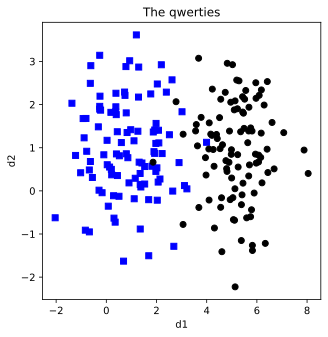

In [4]:
# create data

nPerClust = 100
blur = 1

#specify the center of the data clouds
A = [1,1]
B = [5,1]

# generate data
a = [A[0]+np.random.randn(nPerClust)*blur, A[1]+np.random.randn(nPerClust)*blur]
b = [B[0]+np.random.randn(nPerClust)*blur, B[1]+np.random.randn(nPerClust)*blur]

# true labels
labels_np = np.vstack((np.zeros((nPerClust,1)), np.ones((nPerClust,1))))
# I'm categoryze the data using the sentence above

# concatanate into a matrix
data_np = np.hstack((a,b)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko')
plt.title('The qwerties')
plt.xlabel('d1')
plt.ylabel('d2')
plt.show()

In [5]:
# inpect types
print(type(data_np))
print(np.shape(data_np))
print(' ')

print(type(data))
print(np.shape(data))

<class 'numpy.ndarray'>
(200, 2)
 
<class 'torch.Tensor'>
torch.Size([200, 2])


In [6]:
# build the model
ANNclassify = nn.Sequential(
    nn.Linear(2,1), # input layer
    nn.ReLU(), # activation function
    nn.Linear(1,1), # output layer
    nn.Sigmoid() # activation function (here for conceptual reasons)
  )

ANNclassify

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
  (3): Sigmoid()
)

In [7]:
# other model features

learningRate = 0.01

# loss function
lossfun = nn.BCELoss # NOT USE MSE
# note: you'll learn in the 'metaparameters' section that it's better to se BCEwithLog

# optimizer
optimizer = torch.optim.SGD(ANNclassify.parameters(), lr=learningRate)


In [ ]:
# train the model